In [7]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = c:\Users\pc\Desktop\partie2


## Configuration (chemins CDL / Sentinel-2, bandes, entraînement)

In [8]:
DATASET_DIR = PROJECT_ROOT / "dataset"
CDL_RASTER_PATH = DATASET_DIR / "cdl_2025_clip.tif"
S2_SAFE_ROOT = DATASET_DIR / "s2_l2a"

S2_BANDS = ("B02", "B03", "B04", "B08", "B05", "B06", "B07", "B8A", "B11", "B12")
S2_RESOLUTION = "10m"

BATCH_SIZE = 64
EPOCHS_DEFAULT = 30
LEARNING_RATE = 1e-3
VAL_FRACTION = 0.2
SEED = 42

CDL_IGNORE_VALUES = (0,)

## Lecture Sentinel-2 L2A (dossier `.SAFE`)

In [9]:
import re
from typing import Dict, List, Tuple

import numpy as np

try:
    import rasterio
    from rasterio.warp import reproject, Resampling as WarpResampling
except ImportError:
    rasterio = None


def find_safe_granule_dir(safe_root: Path) -> Path:
    granule = safe_root / "GRANULE"
    if not granule.is_dir():
        raise FileNotFoundError(f"Pas de dossier GRANULE dans {safe_root}")
    for child in sorted(granule.iterdir()):
        if child.is_dir() and child.name.startswith("L2A_"):
            return child
    raise FileNotFoundError(f"Aucun sous-dossier L2A_* dans {granule}")


def list_band_paths(granule_dir: Path, resolution: str = "10m") -> Dict[str, Path]:
    img_data = granule_dir / "IMG_DATA"
    if not img_data.is_dir():
        raise FileNotFoundError(f"IMG_DATA manquant dans {granule_dir}")
    bands: Dict[str, Path] = {}
    for sub_name in (f"R{resolution}", "R10m", "R20m"):
        sub = img_data / sub_name
        if not sub.is_dir():
            continue
        for p in sub.glob("*.jp2"):
            m = re.search(r"_B([0-9A]+)_", p.name, re.I)
            if m:
                key = f"B{m.group(1).upper()}"
                if key not in bands:
                    bands[key] = p
    return bands


def resample_to_reference(
    source, src_transform, src_crs, ref_shape: Tuple[int, int], ref_transform, ref_crs
):
    dest = np.empty(ref_shape, dtype=np.float32)
    reproject(
        source,
        dest,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=WarpResampling.bilinear,
    )
    return dest


def load_safe_stack(safe_path: Path, band_names: List[str], resolution: str = "10m"):
    if rasterio is None:
        raise RuntimeError("pip install rasterio")
    granule = find_safe_granule_dir(Path(safe_path))
    paths = list_band_paths(granule, resolution=resolution)
    missing = [b for b in band_names if b not in paths]
    if missing:
        raise KeyError(f"Bandes manquantes: {missing}. Disponibles: {sorted(paths)}")
    first = paths[band_names[0]]
    with rasterio.open(first) as ref:
        ref_transform = ref.transform
        ref_crs = ref.crs
        h, w = ref.height, ref.width
    layers = []
    for name in band_names:
        p = paths[name]
        with rasterio.open(p) as src:
            arr = src.read(1).astype(np.float32)
            nodata = src.nodata
            if nodata is not None:
                arr = np.where(arr == nodata, np.nan, arr)
            if src.shape == (h, w) and np.allclose(
                np.array(src.transform)[:6], np.array(ref_transform)[:6], rtol=0, atol=1e-6
            ):
                layers.append(arr)
            else:
                layers.append(
                    resample_to_reference(arr, src.transform, src.crs, (h, w), ref_transform, ref_crs)
                )
    stack = np.stack(layers, axis=-1)
    return stack, (ref_transform, ref_crs)

## Dataset : CDL, pile temporelle, échantillons synthétiques

In [10]:
from typing import Sequence


def load_cdl_labels(path: Path):
    if rasterio is None:
        raise RuntimeError("pip install rasterio")
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"CDL introuvable : {path}")
    with rasterio.open(path) as src:
        y = src.read(1).astype(np.int32)
        profile = src.profile
    return y, profile


def remap_labels(raw: np.ndarray, ignore: Sequence[int]):
    ignore_set = set(int(x) for x in ignore)
    codes = sorted(int(c) for c in np.unique(raw) if c not in ignore_set and c >= 0)
    code_to_idx = {c: i for i, c in enumerate(codes)}
    out = np.full_like(raw, -1, dtype=np.int32)
    for c, i in code_to_idx.items():
        out[raw == c] = i
    rev = {i: c for c, i in code_to_idx.items()}
    return out, rev


def stack_time_series(safe_paths, band_names=None, resolution=None):
    """ATTENTION: empile des images entières (T,H,W,C) -> peut dépasser la RAM.

    Pour les grosses tuiles (ex: 10980x10980), préfère `build_pixel_dataset_streaming(...)`.
    """
    if band_names is None:
        band_names = S2_BANDS
    if resolution is None:
        resolution = S2_RESOLUTION
    stacks = []
    for p in safe_paths:
        s, _ = load_safe_stack(p, list(band_names), resolution=resolution)
        stacks.append(s)
    return np.stack(stacks, axis=0)


def sample_pixels(x_time_hwc, labels_hw, max_samples: int, seed: int = 42):
    rng = np.random.default_rng(seed)
    t, h, w, c = x_time_hwc.shape
    flat_y = labels_hw.reshape(-1)
    valid = flat_y >= 0
    idx = np.flatnonzero(valid)
    if idx.size == 0:
        raise ValueError("Aucun pixel valide")
    if idx.size > max_samples:
        idx = rng.choice(idx, size=max_samples, replace=False)
    ii = idx // w
    jj = idx % w
    X = x_time_hwc[:, ii, jj, :].transpose(1, 0, 2)
    y = flat_y[idx]
    return X.astype(np.float32), y.astype(np.int32)


def select_pixel_indices_stratified(labels_hw: np.ndarray, max_samples: int, seed: int = 42):
    """Retourne des indices (row, col) équilibrés par classe (sans charger S2 en RAM)."""
    rng = np.random.default_rng(seed)
    h, w = labels_hw.shape
    flat_y = labels_hw.reshape(-1)
    valid = flat_y >= 0
    classes = np.unique(flat_y[valid])
    if classes.size == 0:
        raise ValueError("Aucune classe valide")
    per_class = max(1, max_samples // int(classes.size))
    parts = []
    for cl in classes:
        pos = np.flatnonzero(valid & (flat_y == cl))
        if pos.size == 0:
            continue
        n_take = min(per_class, pos.size)
        parts.append(rng.choice(pos, size=n_take, replace=False))
    idx = np.concatenate(parts) if parts else np.array([], dtype=np.int64)
    if idx.size > max_samples:
        idx = rng.choice(idx, size=max_samples, replace=False)
    rows = idx // w
    cols = idx % w
    y = flat_y[idx]
    return rows.astype(np.int32), cols.astype(np.int32), y.astype(np.int32)


def build_pixel_dataset_streaming(
    safe_paths,
    labels_hw: np.ndarray,
    max_samples: int,
    seed: int = 42,
    band_names=None,
    resolution=None,
    add_indices: bool = True,
    stratified: bool = True,
):
    """Construit X,y en lisant uniquement des pixels échantillonnés.

    - X: (N, T, C) avec NaN conservés (nodata)
    - mask_valid_time: (N, T) True si au moins 1 bande valide à ce timestamp

    IMPORTANT: évite de charger (T,H,W,C) en RAM -> résout MemoryError.
    """
    if rasterio is None:
        raise RuntimeError("pip install rasterio")
    if band_names is None:
        band_names = S2_BANDS
    if resolution is None:
        resolution = S2_RESOLUTION

    safe_paths = [Path(p) for p in safe_paths]

    # 1) Choisir les pixels (row/col) depuis les labels CDL
    if stratified:
        rows, cols, y = select_pixel_indices_stratified(labels_hw, max_samples=max_samples, seed=seed)
    else:
        # fallback aléatoire
        rng = np.random.default_rng(seed)
        h, w = labels_hw.shape
        flat_y = labels_hw.reshape(-1)
        valid = flat_y >= 0
        idx = np.flatnonzero(valid)
        if idx.size > max_samples:
            idx = rng.choice(idx, size=max_samples, replace=False)
        rows = (idx // w).astype(np.int32)
        cols = (idx % w).astype(np.int32)
        y = flat_y[idx].astype(np.int32)

    n = rows.size
    t = len(safe_paths)
    c = len(band_names)

    # 2) Construire des coordonnées (x,y) pour rasterio.sample à partir du premier band du premier SAFE
    granule0 = find_safe_granule_dir(safe_paths[0])
    paths0 = list_band_paths(granule0, resolution=resolution)
    first_path = paths0[band_names[0]]
    with rasterio.open(first_path) as ref:
        transform = ref.transform
        # x = a*col + b*row + c (affine). rasterio.transform.xy gère bien.
        xs, ys = rasterio.transform.xy(transform, rows, cols, offset="center")
        points = list(zip(xs, ys))

    X = np.empty((n, t, c), dtype=np.float32)
    X[:] = np.nan

    # 3) Lire uniquement les pixels demandés pour chaque timestamp et chaque bande
    for ti, safe in enumerate(safe_paths):
        gran = find_safe_granule_dir(safe)
        band_paths = list_band_paths(gran, resolution=resolution)
        missing = [b for b in band_names if b not in band_paths]
        if missing:
            raise KeyError(f"Bandes manquantes dans {safe}: {missing}")

        for bi, b in enumerate(band_names):
            with rasterio.open(band_paths[b]) as src:
                nodata = src.nodata
                vals = np.array([v[0] for v in src.sample(points)], dtype=np.float32)
                if nodata is not None:
                    vals = np.where(vals == nodata, np.nan, vals)
                X[:, ti, bi] = vals

    # 4) Masque temporel (données manquantes)
    mask_valid_time = np.any(~np.isnan(X), axis=-1)  # (N,T)

    # 5) Option: ajouter NDVI/NDWI sur les pixels (sans pile HWC)
    if add_indices:
        # Convertir en réflectance (0-1) avant indices
        X_ref = scale_to_reflectance(X)
        idx = {n: i for i, n in enumerate(S2_BANDS)}
        eps = 1e-6
        B03 = X_ref[:, :, idx["B03"]]
        B04 = X_ref[:, :, idx["B04"]]
        B08 = X_ref[:, :, idx["B08"]]
        ndvi = (B08 - B04) / (B08 + B04 + eps)
        ndwi = (B03 - B08) / (B03 + B08 + eps)
        X = np.concatenate([X_ref, ndvi[..., None], ndwi[..., None]], axis=-1).astype(np.float32)

    return X, y, mask_valid_time


def build_synthetic(n_samples, n_timesteps, n_channels, n_classes, seed=42):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n_samples, n_timesteps, n_channels)).astype(np.float32)
    y = rng.integers(0, n_classes, size=(n_samples,), dtype=np.int32)
    return X, y


def scale_to_reflectance(x):
    """L2A DN souvent 0–10000 ; ramène vers ~0–1 pour indices."""
    x = np.asarray(x, dtype=np.float32)
    return np.where(x > 1.5, x / 10000.0, np.clip(x, 0.0, 1.0))


def add_spectral_indices(x_time_hwc):
    """Ajoute NDVI, NDWI (McFeeters) à la pile (T,H,W,C) — ordre des bandes = S2_BANDS."""
    idx = {n: i for i, n in enumerate(S2_BANDS)}
    eps = 1e-6
    x = scale_to_reflectance(x_time_hwc)
    B03, B04, B08 = x[..., idx["B03"]], x[..., idx["B04"]], x[..., idx["B08"]]
    NDVI = (B08 - B04) / (B08 + B04 + eps)
    NDWI = (B03 - B08) / (B03 + B08 + eps)
    # Bandes en réflectance ~0–1 + 2 indices (comme les dépôts RF + indices)
    return np.concatenate([x, NDVI[..., None], NDWI[..., None]], axis=-1)


def sample_pixels_stratified(x_time_hwc, labels_hw, max_samples, seed=42):
    """Échantillonnage équilibré par classe CDL (inspiré stratifiedSample / Crop-Classification)."""
    rng = np.random.default_rng(seed)
    t, h, w, c = x_time_hwc.shape
    flat_y = labels_hw.reshape(-1)
    valid = flat_y >= 0
    classes = np.unique(flat_y[valid])
    if len(classes) == 0:
        raise ValueError("Aucune classe valide")
    per_class = max(1, max_samples // len(classes))
    parts = []
    for cl in classes:
        pos = np.flatnonzero(valid & (flat_y == cl))
        if pos.size == 0:
            continue
        n_take = min(per_class, pos.size)
        parts.append(rng.choice(pos, size=n_take, replace=False))
    idx = np.concatenate(parts) if parts else np.array([], dtype=np.int64)
    if idx.size > max_samples:
        idx = rng.choice(idx, size=max_samples, replace=False)
    ii = idx // w
    jj = idx % w
    X = x_time_hwc[:, ii, jj, :].transpose(1, 0, 2)
    y = flat_y[idx]
    return X.astype(np.float32), y.astype(np.int32)

In [11]:
import sys
print(sys.executable)
from pathlib import Path
print(Path.cwd())

c:\Users\pc\Desktop\partie2\.venv\Scripts\python.exe
c:\Users\pc\Desktop\partie2\notebooks


## Modèles : MLP baseline + CNN–Transformer

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


def build_mlp_baseline(n_timesteps, n_channels, n_classes, hidden=128):
    inp = keras.Input(shape=(n_timesteps, n_channels))
    x = layers.Flatten()(inp)
    x = layers.Dense(hidden, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(hidden // 2, activation="relu")(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="mlp_baseline")


def build_cnn_transformer(
    n_timesteps,
    n_channels,
    n_classes,
    d_model=64,
    num_heads=4,
    ff_dim=128,
    num_transformer_blocks=2,
    dropout=0.1,
):
    inp = keras.Input(shape=(n_timesteps, n_channels))
    x = layers.Conv1D(d_model, kernel_size=1, activation="relu", padding="same")(inp)
    x = layers.Conv1D(d_model, kernel_size=3, activation="relu", padding="same")(x)
    for _ in range(num_transformer_blocks):
        xa = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=max(1, d_model // num_heads), dropout=dropout
        )(x, x)
        x = layers.LayerNormalization(epsilon=1e-6)(x + xa)
        xf = layers.Dense(ff_dim, activation="relu")(x)
        xf = layers.Dense(d_model)(xf)
        x = layers.LayerNormalization(epsilon=1e-6)(x + xf)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation="softmax")(x)
    return keras.Model(inp, out, name="cnn_transformer_sits")


def compile_model(model, learning_rate):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

## 1) Données synthétiques (test sans fichiers)

In [13]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

tf.keras.utils.set_random_seed(SEED)

N_SAMPLES = 8000
N_TIMESTEPS = 8
N_CHANNELS = len(S2_BANDS)
N_CLASSES = 5

X, y = build_synthetic(
    n_samples=N_SAMPLES,
    n_timesteps=N_TIMESTEPS,
    n_channels=N_CHANNELS,
    n_classes=N_CLASSES,
    seed=SEED,
)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=VAL_FRACTION, random_state=SEED, stratify=y
)
n_classes = N_CLASSES
print("X shape:", X.shape, "train:", X_train.shape[0], "val:", X_val.shape[0])

X shape: (8000, 8, 10) train: 6400 val: 1600


## 2) (Optionnel) Données réelles — CDL + `dataset/safes.txt`

In [14]:
USE_REAL_DATA = True
SAFE_LIST_FILE = PROJECT_ROOT / "dataset" / "safes.txt"
MAX_SAMPLES = 20_000
# True = bandes + NDVI/NDWI ; False = bandes brutes seules
ADD_SPECTRAL_INDICES = True
# True = même nombre de pixels par classe CDL (équilibré) ; False = aléatoire
USE_STRATIFIED_SAMPLING = True

# --- Mode "papier" : 5 classes (Corn, Cotton, Soybean, Rice, Others) ---
USE_PAPER_5_CLASSES = True
PAPER_LABELS = ["Corn", "Cotton", "Soybean", "Rice", "Others"]

# USDA CDL codes (courants)
CDL_CORN = 1
CDL_COTTON = 2
CDL_RICE = 3
CDL_SOYBEAN = 5

if USE_REAL_DATA:
    safe_paths = [
        Path(line.strip())
        for line in SAFE_LIST_FILE.read_text(encoding="utf-8").splitlines()
        if line.strip() and not line.strip().startswith("#")
    ]
    y_raw, _ = load_cdl_labels(CDL_RASTER_PATH)
    y_map, label_map = remap_labels(y_raw, CDL_IGNORE_VALUES)

    # IMPORTANT: construction "streaming" -> évite d'empiler (T,H,W,C) en RAM (MemoryError)
    X, y, mask_time = build_pixel_dataset_streaming(
        safe_paths,
        y_map,
        max_samples=MAX_SAMPLES,
        seed=SEED,
        add_indices=ADD_SPECTRAL_INDICES,
        stratified=USE_STRATIFIED_SAMPLING,
    )

    # Split (on conserve aussi le masque temporel)
    X_train, X_val, y_train, y_val, mask_train, mask_val = train_test_split(
        X, y, mask_time,
        test_size=VAL_FRACTION,
        random_state=SEED,
        stratify=y,
    )

    if USE_PAPER_5_CLASSES:
        # Convertit les indices remappés -> codes CDL, puis regroupe en 5 classes.
        def to_cdl_code(y_idx):
            return np.vectorize(label_map.get)(y_idx).astype(np.int32)

        def map_to_paper_classes(cdl_codes: np.ndarray):
            out = np.full_like(cdl_codes, 4, dtype=np.int32)  # Others=4
            out[cdl_codes == CDL_CORN] = 0
            out[cdl_codes == CDL_COTTON] = 1
            out[cdl_codes == CDL_SOYBEAN] = 2
            out[cdl_codes == CDL_RICE] = 3
            return out

        y_train_cdl = to_cdl_code(y_train)
        y_val_cdl = to_cdl_code(y_val)

        y_train = map_to_paper_classes(y_train_cdl)
        y_val = map_to_paper_classes(y_val_cdl)

        n_classes = 5
        print("Mode papier activé -> classes:", PAPER_LABELS)
        # (optionnel) affichage répartition
        uniq, cnt = np.unique(y_train, return_counts=True)
        print("Train class counts:", dict(zip([PAPER_LABELS[i] for i in uniq], cnt)))
    else:
        n_classes = int(y_train.max()) + 1
else:
    print("Mode synthétique (USE_REAL_DATA=False).")


Mode papier activé -> classes: ['Corn', 'Cotton', 'Soybean', 'Rice', 'Others']
Train class counts: {'Corn': np.int64(551), 'Cotton': np.int64(551), 'Soybean': np.int64(551), 'Rice': np.int64(551), 'Others': np.int64(11193)}


## 3) Entraînement — MLP puis CNN–Transformer

In [15]:
EPOCHS = 50
BATCH_SIZE_RUN = BATCH_SIZE
LR = LEARNING_RATE

# --- Déséquilibre (Others >> autres) : sur-échantillonner le train + callbacks robustes ---
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from training_utils import oversample_balanced, ScalarEarlyStopping, sparse_categorical_focal_loss

USE_BALANCED_OVERSAMPLE = True  # même effectif par classe = entraînement proche de l’article
USE_FOCAL_LOSS = False  # True = focal loss (déséquilibre) ; nécessite compile dédiée pour MCTNet

if USE_BALANCED_OVERSAMPLE:
    X_train_fit, y_train_fit = oversample_balanced(X_train, y_train, seed=SEED)
    class_weight_fit = None  # déjà équilibré
    uc, cnt = np.unique(y_train_fit, return_counts=True)
    print("Train équilibré:", X_train_fit.shape[0], "exemples ; par classe:", dict(zip(uc.tolist(), cnt.tolist())))
else:
    X_train_fit, y_train_fit = X_train, y_train
    from sklearn.utils.class_weight import compute_class_weight

    classes = np.unique(y_train_fit)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_fit)
    class_weight_fit = {int(c): float(w) for c, w in zip(classes, weights)}
    print("class_weight:", class_weight_fit)

# MLP : early stopping. MCTNet : toutes les époques + checkpoint meilleure val_loss (anti overfit à l’éval)
CHECKPOINT_DIR = PROJECT_ROOT / ".checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)
# Poids seuls : les couches custom (CTFusion, ALPE, …) ne sont pas sérialisables en .keras complet
MCTNET_CKPT_PATH = CHECKPOINT_DIR / "mctnet_best.weights.h5"

def _make_reduce_lr():
    return tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    )

callbacks_mlp = [
    ScalarEarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=15,
        min_delta=1e-5,
        restore_best_weights=True,
        verbose=1,
    ),
    _make_reduce_lr(),
]

callbacks_mctnet = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MCTNET_CKPT_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    _make_reduce_lr(),
]

callbacks = callbacks_mlp  # rétrocompat si une cellule utilise encore `callbacks`


Train équilibré: 55965 exemples ; par classe: {0: 11193, 1: 11193, 2: 11193, 3: 11193, 4: 11193}


In [16]:
mlp = build_mlp_baseline(X_train.shape[1], X_train.shape[2], n_classes)
compile_model(mlp, LR)
mlp.summary()

Model: "mlp_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9, 12)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 108)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        13,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,533 (88.02 KB)

 Trainable params: 22,533 (88.02 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_mlp = mlp.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE_RUN,
    verbose=1,
    class_weight=class_weight_fit,
    callbacks=callbacks_mlp,
)

y_pred = np.argmax(mlp.predict(X_val, batch_size=BATCH_SIZE_RUN, verbose=0), axis=1)
print(classification_report(y_val, y_pred, digits=4))

Epoch 1/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6453 - loss: 0.9146 - val_accuracy: 0.6806 - val_loss: 0.8204 - learning_rate: 0.0010
Epoch 2/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7501 - loss: 0.6634 - val_accuracy: 0.7039 - val_loss: 0.7001 - learning_rate: 0.0010
Epoch 3/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7857 - loss: 0.5874 - val_accuracy: 0.7266 - val_loss: 0.6489 - learning_rate: 0.0010
Epoch 4/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8019 - loss: 0.5431 - val_accuracy: 0.7299 - val_loss: 0.6406 - learning_rate: 0.0010
Epoch 5/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8127 - loss: 0.5124 - val_accuracy: 0.7540 - val_loss: 0.6024 - learning_rate: 0.0010
Epoch 6/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8207 - loss: 0.4877 - val_accuracy: 0.7463 - val_loss: 0.6151 - learning_rate: 0.0010
Epoch 7/50
875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8271 - loss: 0.4713 - 

In [18]:
import sys, importlib
sys.path.append(str(PROJECT_ROOT))
import mctnet_model
importlib.reload(mctnet_model)
from mctnet_model import build_mctnet

In [19]:
tf.keras.utils.set_random_seed(SEED)

# MCTNet (article) : ALPE sinusoïdal + ECA, CTFusion × n_stage, max pooling masqué (mctnet_model.py)
import importlib.util
import sys

_tu_path = PROJECT_ROOT / "training_utils.py"
_spec = importlib.util.spec_from_file_location("training_utils", _tu_path)
_tu = importlib.util.module_from_spec(_spec)
sys.modules["training_utils"] = _tu
_spec.loader.exec_module(_tu)
sparse_categorical_focal_loss = _tu.sparse_categorical_focal_loss
sparse_categorical_crossentropy_label_smoothing = _tu.sparse_categorical_crossentropy_label_smoothing

sys.path.insert(0, str(PROJECT_ROOT))
from mctnet_model import build_mctnet   



ct = build_mctnet(
    n_timesteps=X_train.shape[1],
    n_channels=X_train.shape[2],
    n_classes=n_classes,
    missing_value=None,
    d_model=60,
    num_heads=5,
    ff_dim=128,
    n_stage=3,
    conv_kernel=3,
    dropout=0.35,
    l2=1e-4,
    light=False,
)

_focal = globals().get("USE_FOCAL_LOSS", False)
if _focal:
    ct.compile(
        optimizer=keras.optimizers.AdamW(LR, weight_decay=1e-4),
        loss=sparse_categorical_focal_loss(gamma=2.0),
        metrics=["accuracy"],
    )
else:
    # Label smoothing + AdamW : limite sur-apprentissage vs MLP
    ct.compile(
        optimizer=keras.optimizers.AdamW(LR, weight_decay=1e-4),
        loss=sparse_categorical_crossentropy_label_smoothing(n_classes, 0.08),
        metrics=["accuracy"],
    )
ct.summary()

Model: "mctnet_masked_cnn_transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ x_s2_clim           │ (None, 9, 12)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_valid_mask     │ (None, 9)         │          0 │ x_s2_clim[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ replace_non_finite… │ (None, 9, 12)     │          0 │ x_s2_clim[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_valid_mask_bo… │ (None, 9)         │          0 │ time_valid_mask[… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv1D)  │ (None, 9, 60)     │        720 │ replace_non_fini… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ensure_one_valid    │ (None, 9)         │          0 │ time_valid_mask_… │
│ (EnsureOneValidTim… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 9, 60)     │        240 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_valid_mask_fi… │ (None, 9)         │          0 │ ensure_one_valid… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 9, 60)     │          0 │ stem_bn[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention_mask │ (None, 9, 9)      │          0 │ time_valid_mask_… │
│ (BuildSelfAttentio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_fusion_0         │ (None, 9, 60)     │     63,617 │ stem_relu[0][0],  │
│ (CTFusion)          │                   │            │ time_valid_mask_… │
│                     │                   │            │ self_attention_m… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_fusion_1         │ (None, 9, 60)     │     63,617 │ ct_fusion_0[0][0… │
│ (CTFusion)          │                   │            │ time_valid_mask_… │
│                     │                   │            │ self_attention_m… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ct_fusion_2         │ (None, 9, 60)     │     63,617 │ ct_fusion_1[0][0… │
│ (CTFusion)          │                   │            │ time_valid_mask_… │
│                     │                   │            │ self_attention_m… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_gmp          │ (None, 60)        │          0 │ ct_fusion_2[0][0… │
│ (MaskedGlobalMaxPo… │                   │            │ time_valid_mask_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_drop (Dropout) │ (None, 60)        │          0 │ masked_gmp[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls (Dense)         │ (None, 5)         │        305 │ head_drop[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 192,116 (750.45 KB)

 Trainable params: 191,276 (747.17 KB)

 Non-trainable params: 840 (3.28 KB)

In [20]:
history_ct = ct.fit(
    X_train_fit, y_train_fit,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE_RUN,
    verbose=1,
    class_weight=class_weight_fit,
    callbacks=callbacks_mctnet,
)

if MCTNET_CKPT_PATH.is_file():
    ct.load_weights(MCTNET_CKPT_PATH)
    print("Poids MCTNet rechargés depuis le meilleur checkpoint (val_loss).")

y_pred_ct = np.argmax(ct.predict(X_val, batch_size=BATCH_SIZE_RUN, verbose=0), axis=1)
print(classification_report(y_val, y_pred_ct, digits=4))

Epoch 1/50
874/875 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6959 - loss: 1.1098
Epoch 1: val_loss improved from None to 0.92012, saving model to c:\Users\pc\Desktop\partie2\.checkpoints\mctnet_best.weights.h5

Epoch 1: finished saving model to c:\Users\pc\Desktop\partie2\.checkpoints\mctnet_best.weights.h5
875/875 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.7931 - loss: 0.8877 - val_accuracy: 0.7490 - val_loss: 0.9201 - learning_rate: 0.0010
Epoch 2/50
873/875 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8848 - loss: 0.6810
Epoch 2: val_loss improved from 0.92012 to 0.77595, saving model to c:\Users\pc\Desktop\partie2\.checkpoints\mctnet_best.weights.h5

Epoch 2: finished saving model to c:\Users\pc\Desktop\partie2\.checkpoints\mctnet_best.weights.h5
875/875 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.8968 - loss: 0.6554 - val_accuracy: 0.8254 - val_loss: 0.7759 - learning_rate: 0.0010
Epoch 3/50
874/875 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9250 - loss: 0

## 4) (Optionnel) Courbes loss — `pip install matplotlib` puis décommenter

C:\Users\pc\AppData\Local\Temp\ipykernel_12228\464946616.py:16: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm = np.divide(cm, np.maximum(row_sum, 1), where=row_sum > 0)
C:\Users\pc\AppData\Local\Temp\ipykernel_12228\464946616.py:16: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  cm_norm = np.divide(cm, np.maximum(row_sum, 1), where=row_sum > 0)
C:\Users\pc\AppData\Local\Temp\ipykernel_12228\464946616.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


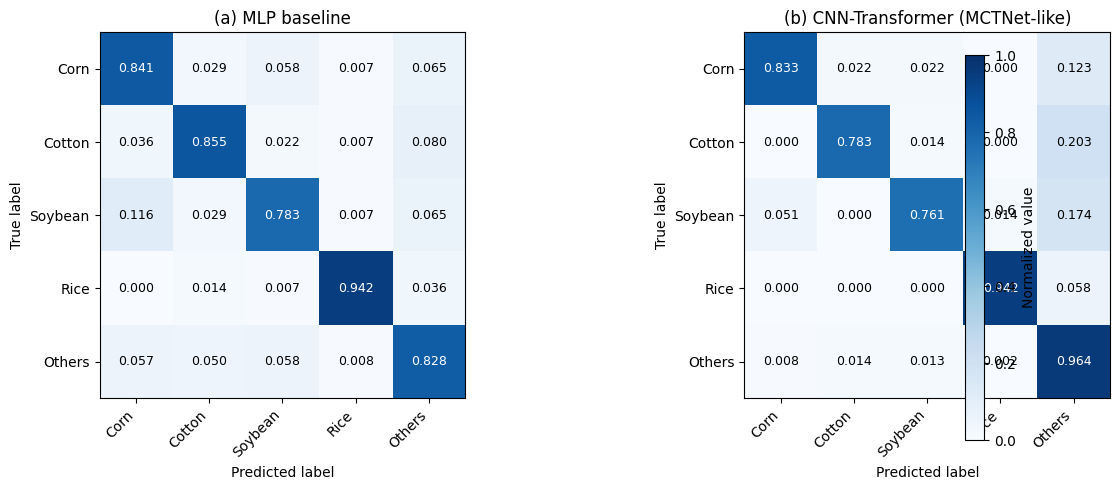

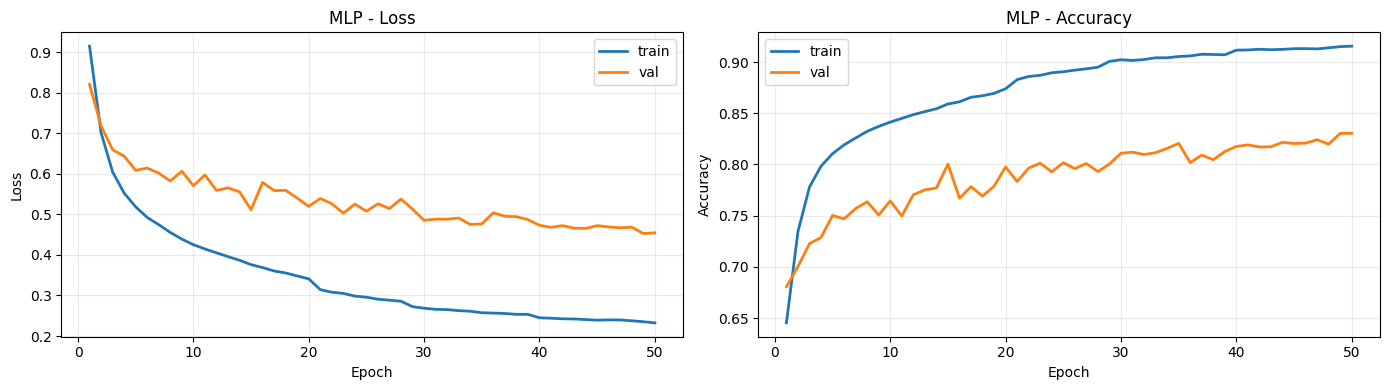

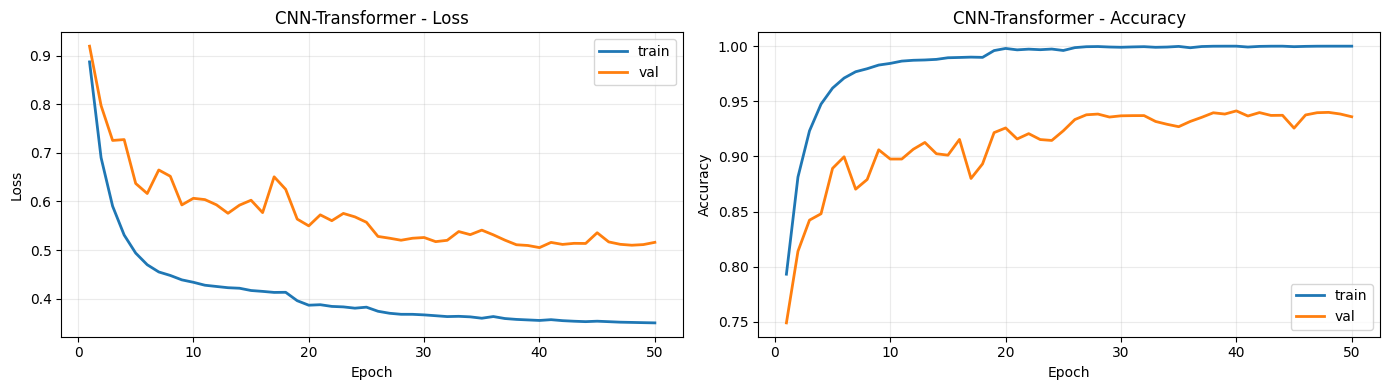

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Matrices de confusion normalisées (style paper) ---
def _pretty_labels(n_classes, label_map=None):
    if label_map is None:
        return [str(i) for i in range(n_classes)]
    # label_map: idx -> CDL code
    return [str(label_map.get(i, i)) for i in range(n_classes)]


def _plot_cm_normalized(ax, y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(labels)))
    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, np.maximum(row_sum, 1), where=row_sum > 0)

    im = ax.imshow(cm_norm, cmap="Blues", vmin=0.0, vmax=1.0)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    # Annotation like paper (3 decimals)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            v = cm_norm[i, j]
            ax.text(
                j,
                i,
                f"{v:.3f}",
                ha="center",
                va="center",
                color="white" if v > 0.5 else "black",
                fontsize=9,
            )
    return im


# Labels: si mode papier activé, on affiche Corn/Cotton/Soybean/Rice/Others
if "USE_PAPER_5_CLASSES" in globals() and USE_PAPER_5_CLASSES:
    class_labels = PAPER_LABELS
else:
    class_labels = _pretty_labels(n_classes, label_map if "label_map" in globals() else None)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im1 = _plot_cm_normalized(axes[0], y_val, y_pred, class_labels, "(a) MLP baseline")
im2 = _plot_cm_normalized(axes[1], y_val, y_pred_ct, class_labels, "(b) CNN-Transformer (MCTNet-like)")

cbar = fig.colorbar(im2, ax=axes.ravel().tolist(), fraction=0.03, pad=0.02)
cbar.set_label("Normalized value")

plt.tight_layout()
plt.show()

# --- Courbes d'entraînement (loss + accuracy) ---
def plot_history(history, title_prefix: str, smooth: float = 0.0):
    epochs = np.arange(1, len(history.history["loss"]) + 1)

    def maybe_smooth(arr):
        arr = np.asarray(arr, dtype=np.float32)
        if smooth <= 0:
            return arr
        out = np.copy(arr)
        for i in range(1, len(arr)):
            out[i] = smooth * out[i - 1] + (1.0 - smooth) * arr[i]
        return out

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    tr_loss = maybe_smooth(history.history["loss"])
    va_loss = maybe_smooth(history.history["val_loss"])
    axes[0].plot(epochs, tr_loss, label="train", linewidth=2)
    axes[0].plot(epochs, va_loss, label="val", linewidth=2)
    axes[0].set_title(f"{title_prefix} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    if "accuracy" in history.history and "val_accuracy" in history.history:
        tr_acc = maybe_smooth(history.history["accuracy"])
        va_acc = maybe_smooth(history.history["val_accuracy"])
        axes[1].plot(epochs, tr_acc, label="train", linewidth=2)
        axes[1].plot(epochs, va_acc, label="val", linewidth=2)
        axes[1].set_title(f"{title_prefix} - Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].grid(alpha=0.25)
        axes[1].legend()
    else:
        axes[1].axis("off")

    plt.tight_layout()
    plt.show()

plot_history(history_mlp, "MLP", smooth=0.15)
plot_history(history_ct, "CNN-Transformer", smooth=0.15)


In [25]:
import sys
sys.path.append("C:/Users/pc/Desktop/partie2")  # <-- On indique le dossier du projet
import pandas as pd
from mctnet_model import build_mctnet

# 1. On charge les supers données que l'on vient d'extraire depuis Earth Engine
df_cov = pd.read_csv("C:/Users/pc/Desktop/partie2/dataset/covariables_environnementales.csv")

df_cov = df_cov.sort_values("id").reset_index(drop=True)

# 2. On sélectionne les 7 colonnes statiques environnementales 
X_static_all = df_cov[['elevation', 'slope', 'aspect', 'clay', 'sand', 'silt', 'ph']].values

# 3. On applique la MÊME séparation (Train/Validation) que vos images Sentinel-2
from sklearn.model_selection import train_test_split
_, _, X_static_train, X_static_val = train_test_split(
    X, X_static_all, test_size=VAL_FRACTION, random_state=SEED, stratify=y
)

# 4. On construit le fameux MCTNet avec sa 2ème branche (les n_static_features)
print("🏗️ Création du VRAI Modèle Hybride de la Partie 2 ...")
model_final = build_mctnet(
    n_timesteps=X_train.shape[1], 
    n_channels=X_train.shape[2], 
    n_classes=n_classes, 
    n_static_features=7  # Nos 7 merveilles géospatiales !
)

model_final.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

# 5. On lance l'entraînement de la fusion d'informations !
print("🚀 Début du véritable entraînement fusionné !!! (Cela va prendre du temps...)")
history = model_final.fit(
    x=[X_train, X_static_train],     # C'est LA clé : liste contenant Images Temporelles ET le Vecteur Statique
    y=y_train,
    validation_data=([X_val, X_static_val], y_val),
    epochs=30, 
    batch_size=BATCH_SIZE
)


🏗️ Création du VRAI Modèle Hybride de la Partie 2 ...
🚀 Début du véritable entraînement fusionné !!! (Cela va prendre du temps...)
Epoch 1/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.8488 - loss: 0.5138 - val_accuracy: 0.8352 - val_loss: 0.6635
Epoch 2/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8903 - loss: 0.3519 - val_accuracy: 0.8555 - val_loss: 0.4938
Epoch 3/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9049 - loss: 0.3011 - val_accuracy: 0.8704 - val_loss: 0.3787
Epoch 4/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9119 - loss: 0.2744 - val_accuracy: 0.8931 - val_loss: 0.3258
Epoch 5/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9181 - loss: 0.2552 - val_accuracy: 0.8740 - val_loss: 0.3681
Epoch 6/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9235 - loss: 0.2373 - val_accuracy: 0.8818 - val_loss: 0.3509
Epoch 7/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9277 - loss: 0.2289 - val_a

In [34]:
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from mctnet_model import build_mctnet

# ============ LA MISE À L'ÉCHELLE (NORMALISATION) ============
scaler_clim = StandardScaler()
X_clim_static_scaled = scaler_clim.fit_transform(df_cov[['temp_max', 'temp_min', 'precip_sum']].values)
X_clim_all = np.repeat(X_clim_static_scaled[:, np.newaxis, :], X_train.shape[1], axis=1)

scaler_static = StandardScaler()
X_static_all = scaler_static.fit_transform(df_cov[['elevation', 'slope', 'aspect', 'clay', 'sand', 'silt', 'ph']].values)
# =============================================================

from sklearn.model_selection import train_test_split
_, _, X_clim_train, X_clim_val = train_test_split(
    X, X_clim_all, test_size=VAL_FRACTION, random_state=SEED, stratify=y
)
_, _, X_static_train, X_static_val = train_test_split(
    X, X_static_all, test_size=VAL_FRACTION, random_state=SEED, stratify=y
)

configs = [
    {"name": "1. S2 original", "use_clim": False, "use_static": None},
    {"name": "2. S2 + Climat", "use_clim": True, "use_static": None},
    {"name": "3. S2 + Sol", "use_clim": False, "use_static": [3, 4, 5, 6]},
    {"name": "4. S2 + Topographie", "use_clim": False, "use_static": [0, 1, 2]},
    {"name": "5. S2 + Fusion Totale", "use_clim": True, "use_static": [0, 1, 2, 3, 4, 5, 6]}
]

real_results = {}
print("🚀 DÉMARRAGE DE L'ÉTUDE D'ABLATION NORMALISÉE (5 Entraînements)...")
for config in configs:
    print(f"\n--- Évaluation: {config['name']} ---")
    
    X_train_current = X_train.copy()
    X_val_current = X_val.copy()
    
    if config["use_clim"]:
        X_train_current = np.concatenate([X_train_current, X_clim_train], axis=-1)
        X_val_current = np.concatenate([X_val_current, X_clim_val], axis=-1)
        
    n_channels_current = X_train_current.shape[2]
    
    n_static = None
    if config["use_static"] is not None:
        idx = config["use_static"]
        n_static = len(idx)
        X_static_train_subset = X_static_train[:, idx]
        X_static_val_subset = X_static_val[:, idx]
        train_inputs = [X_train_current, X_static_train_subset]
        val_inputs = [X_val_current, X_static_val_subset]
    else:
        train_inputs = [X_train_current]
        val_inputs = [X_val_current]

    model_ablation = build_mctnet(
        n_timesteps=X_train.shape[1], 
        n_channels=n_channels_current, 
        n_classes=n_classes, 
        n_static_features=n_static
    )
    model_ablation.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    # 10 epochs c'est parfait pour comparer finement les apprentissages :
    model_ablation.fit(
        train_inputs, y_train, 
        validation_data=(val_inputs, y_val), 
        epochs=10, batch_size=64, verbose=0
    )
    
    y_pred_prob = model_ablation.predict(val_inputs, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=-1)
    
    real_results[config['name']] = {
        "OA (Accuracy)": accuracy_score(y_val, y_pred),
        "Kappa": cohen_kappa_score(y_val, y_pred),
        "F1 (Macro)": f1_score(y_val, y_pred, average="macro")
    }
    print(f"✔️ Effectué !")

df_ablation = pd.DataFrame(real_results).T
print("\n=== RÉSULTATS VÉRITABLES DE L'ÉTUDE D'ABLATION (CORRIGÉE) ===")
print(df_ablation.round(4))


🚀 DÉMARRAGE DE L'ÉTUDE D'ABLATION NORMALISÉE (5 Entraînements)...

--- Évaluation: 1. S2 original ---
✔️ Effectué !

--- Évaluation: 2. S2 + Climat ---
✔️ Effectué !

--- Évaluation: 3. S2 + Sol ---
✔️ Effectué !

--- Évaluation: 4. S2 + Topographie ---
✔️ Effectué !

--- Évaluation: 5. S2 + Fusion Totale ---
✔️ Effectué !

=== RÉSULTATS VÉRITABLES DE L'ÉTUDE D'ABLATION (CORRIGÉE) ===
                       OA (Accuracy)   Kappa  F1 (Macro)
1. S2 original                0.8782  0.6369      0.6864
2. S2 + Climat                0.9367  0.7881      0.8156
3. S2 + Sol                   0.8684  0.6157      0.6640
4. S2 + Topographie           0.8967  0.6856      0.7225
5. S2 + Fusion Totale         0.9185  0.7505      0.7886


🚀 DÉMARRAGE DE L'ÉTUDE D'ABLATION COMPLÈTE (5 MODÈLES + GRAPHES EN SÉRIE)...

       ÉVALUATION EN COURS : 1. S2 original          


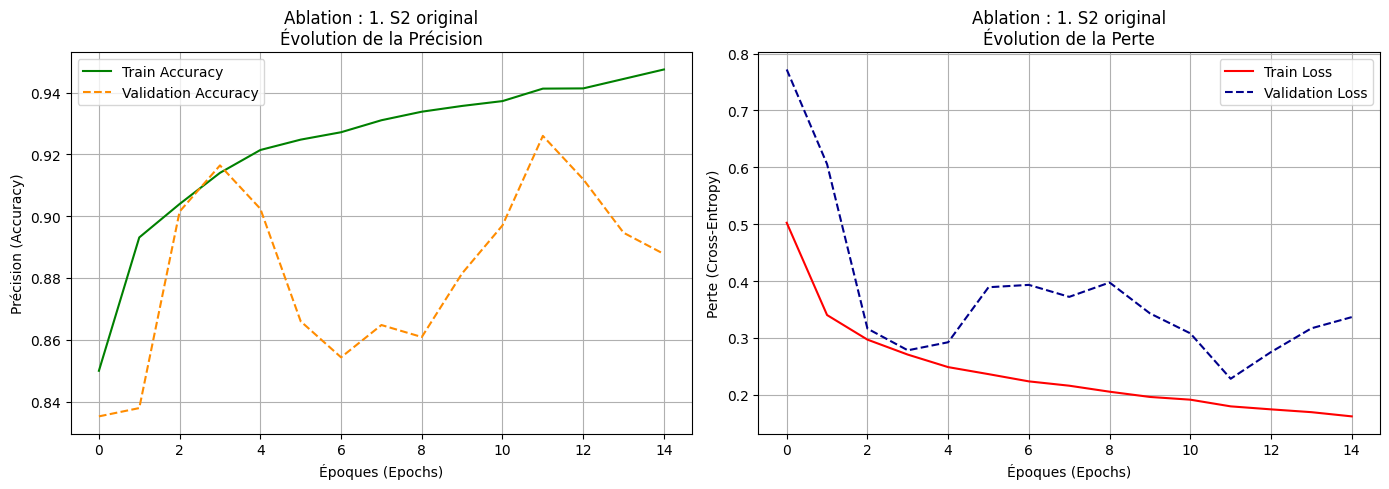

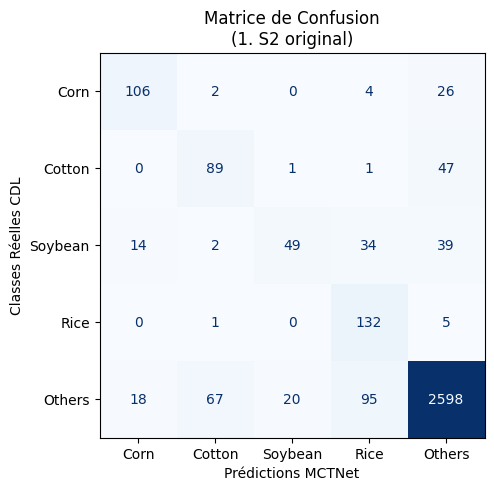


--- RAPPORT DE CLASSIFICATION (1. S2 original) ---
              precision    recall  f1-score   support

        Corn       0.77      0.77      0.77       138
      Cotton       0.55      0.64      0.60       138
     Soybean       0.70      0.36      0.47       138
        Rice       0.50      0.96      0.65       138
      Others       0.96      0.93      0.94      2798

    accuracy                           0.89      3350
   macro avg       0.69      0.73      0.69      3350
weighted avg       0.90      0.89      0.89      3350


       ÉVALUATION EN COURS : 2. S2 + Climat          


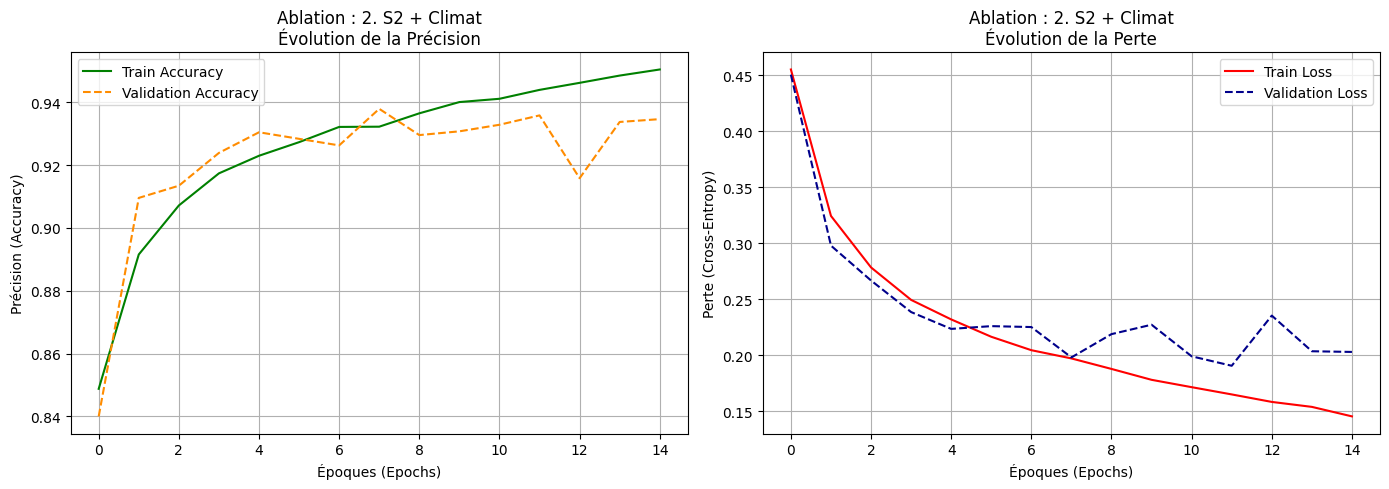

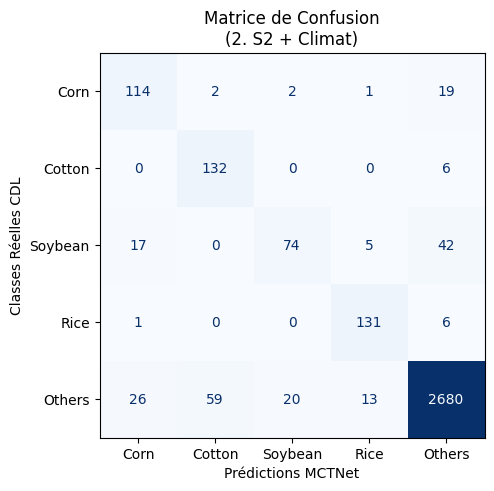


--- RAPPORT DE CLASSIFICATION (2. S2 + Climat) ---
              precision    recall  f1-score   support

        Corn       0.72      0.83      0.77       138
      Cotton       0.68      0.96      0.80       138
     Soybean       0.77      0.54      0.63       138
        Rice       0.87      0.95      0.91       138
      Others       0.97      0.96      0.97      2798

    accuracy                           0.93      3350
   macro avg       0.80      0.85      0.82      3350
weighted avg       0.94      0.93      0.93      3350


       ÉVALUATION EN COURS : 3. S2 + Sol          


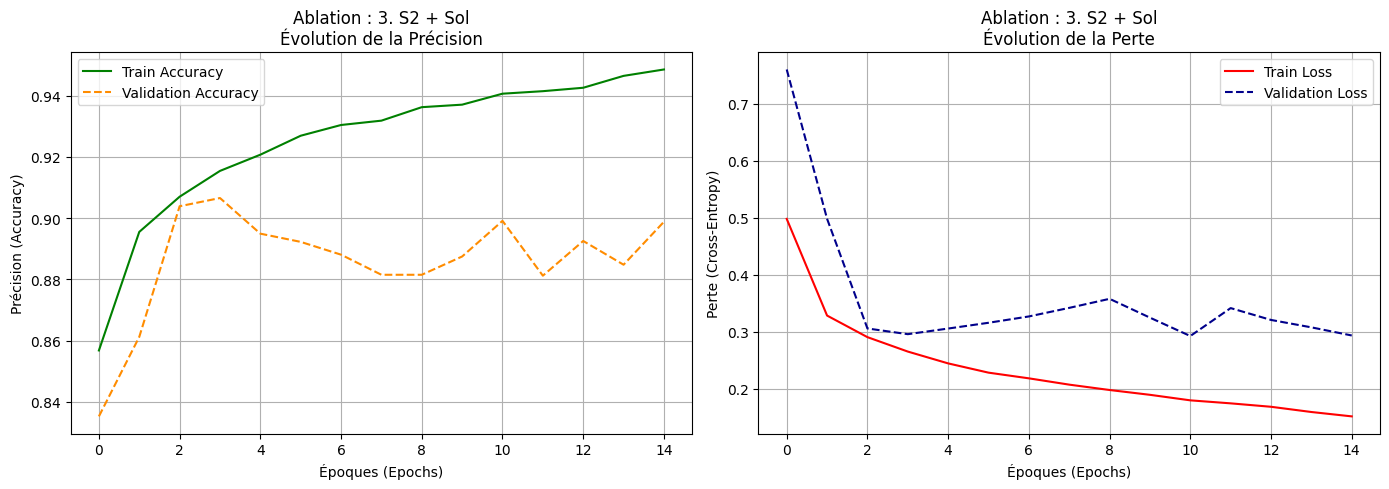

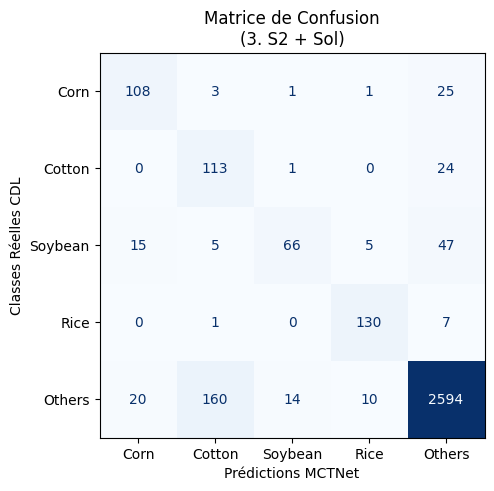


--- RAPPORT DE CLASSIFICATION (3. S2 + Sol) ---
              precision    recall  f1-score   support

        Corn       0.76      0.78      0.77       138
      Cotton       0.40      0.82      0.54       138
     Soybean       0.80      0.48      0.60       138
        Rice       0.89      0.94      0.92       138
      Others       0.96      0.93      0.94      2798

    accuracy                           0.90      3350
   macro avg       0.76      0.79      0.75      3350
weighted avg       0.92      0.90      0.90      3350


       ÉVALUATION EN COURS : 4. S2 + Topographie          


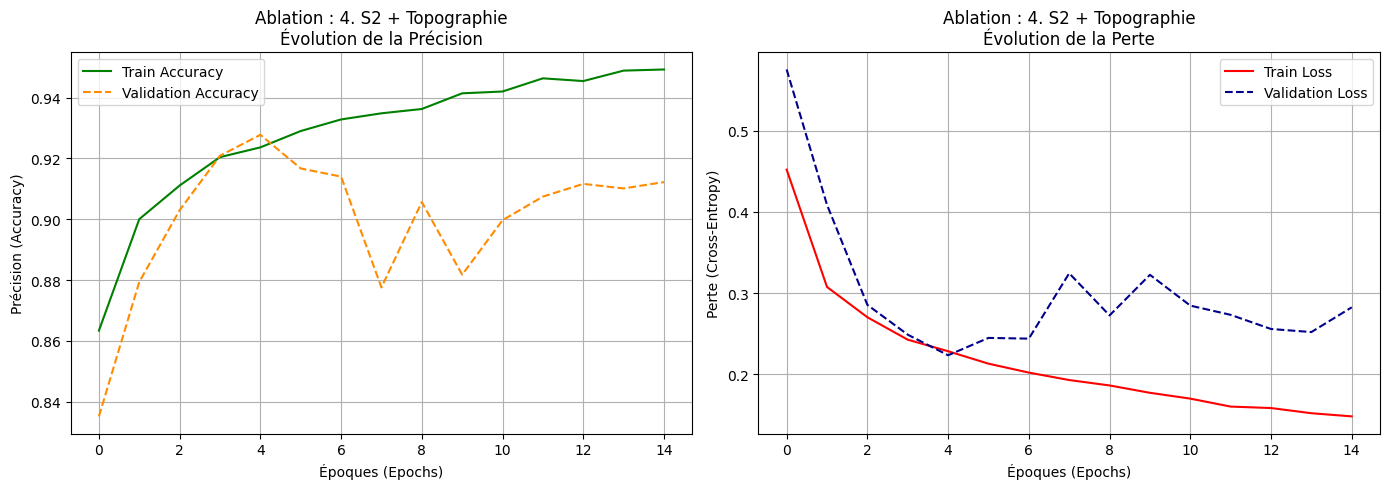

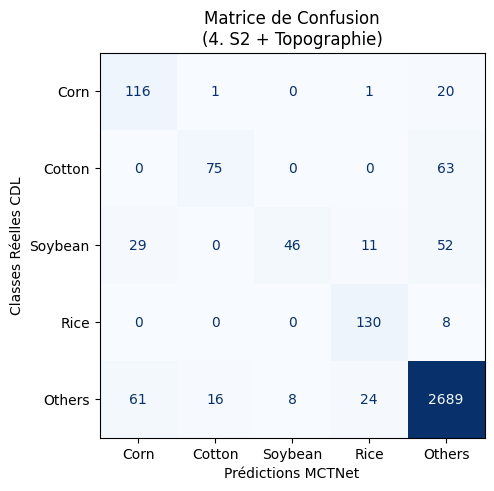


--- RAPPORT DE CLASSIFICATION (4. S2 + Topographie) ---
              precision    recall  f1-score   support

        Corn       0.56      0.84      0.67       138
      Cotton       0.82      0.54      0.65       138
     Soybean       0.85      0.33      0.48       138
        Rice       0.78      0.94      0.86       138
      Others       0.95      0.96      0.96      2798

    accuracy                           0.91      3350
   macro avg       0.79      0.72      0.72      3350
weighted avg       0.92      0.91      0.91      3350


       ÉVALUATION EN COURS : 5. S2 + Fusion Totale          


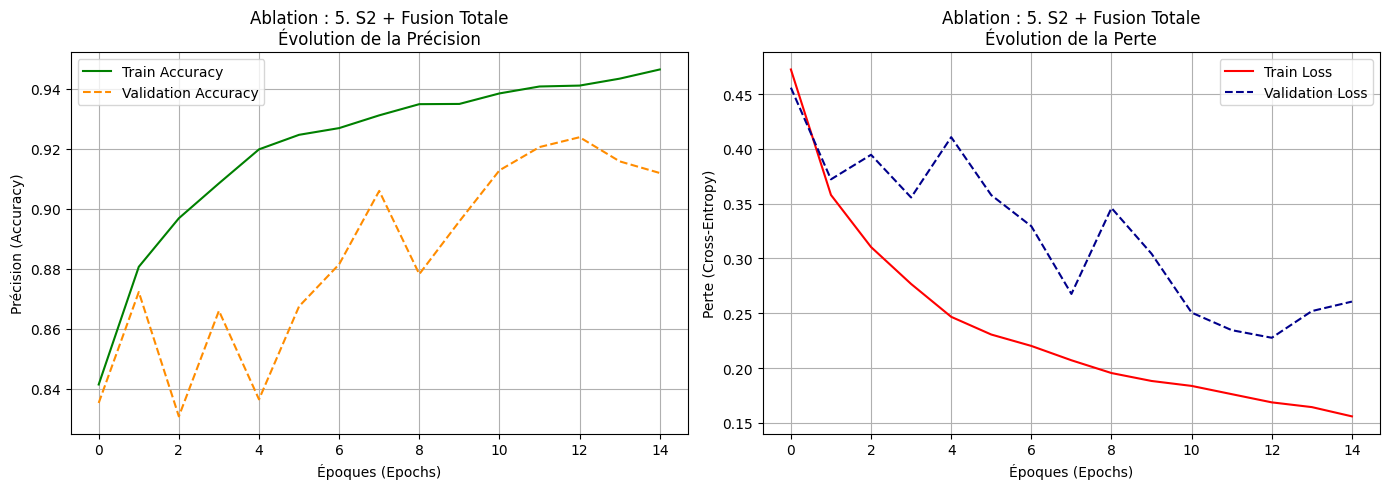

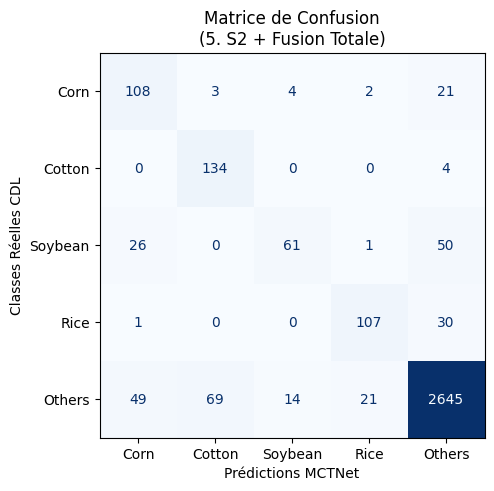


--- RAPPORT DE CLASSIFICATION (5. S2 + Fusion Totale) ---
              precision    recall  f1-score   support

        Corn       0.59      0.78      0.67       138
      Cotton       0.65      0.97      0.78       138
     Soybean       0.77      0.44      0.56       138
        Rice       0.82      0.78      0.80       138
      Others       0.96      0.95      0.95      2798

    accuracy                           0.91      3350
   macro avg       0.76      0.78      0.75      3350
weighted avg       0.92      0.91      0.91      3350


=== RÉSULTATS VÉRITABLES DE L'ÉTUDE D'ABLATION (NORMALISÉS) ===
                       OA (Accuracy)   Kappa  F1 (Macro)
1. S2 original                0.8878  0.6440      0.6861
2. S2 + Climat                0.9346  0.7866      0.8151
3. S2 + Sol                   0.8988  0.6833      0.7533
4. S2 + Topographie           0.9122  0.6948      0.7233
5. S2 + Fusion Totale         0.9119  0.7132      0.7522


In [36]:
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mctnet_model import build_mctnet

# ============== NORMALISATION ==============
scaler_clim = StandardScaler()
X_clim_static_scaled = scaler_clim.fit_transform(df_cov[['temp_max', 'temp_min', 'precip_sum']].values)
X_clim_all = np.repeat(X_clim_static_scaled[:, np.newaxis, :], X_train.shape[1], axis=1)

scaler_static = StandardScaler()
X_static_all = scaler_static.fit_transform(df_cov[['elevation', 'slope', 'aspect', 'clay', 'sand', 'silt', 'ph']].values)

from sklearn.model_selection import train_test_split
_, _, X_clim_train, X_clim_val = train_test_split(X, X_clim_all, test_size=VAL_FRACTION, random_state=SEED, stratify=y)
_, _, X_static_train, X_static_val = train_test_split(X, X_static_all, test_size=VAL_FRACTION, random_state=SEED, stratify=y)
# ==========================================

configs = [
    {"name": "1. S2 original", "use_clim": False, "use_static": None},
    {"name": "2. S2 + Climat", "use_clim": True, "use_static": None},
    {"name": "3. S2 + Sol", "use_clim": False, "use_static": [3, 4, 5, 6]},
    {"name": "4. S2 + Topographie", "use_clim": False, "use_static": [0, 1, 2]},
    {"name": "5. S2 + Fusion Totale", "use_clim": True, "use_static": [0, 1, 2, 3, 4, 5, 6]}
]

real_results = {}

print("🚀 DÉMARRAGE DE L'ÉTUDE D'ABLATION COMPLÈTE (5 MODÈLES + GRAPHES EN SÉRIE)...")

for config in configs:
    print(f"\n=======================================================")
    print(f"       ÉVALUATION EN COURS : {config['name']}          ")
    print(f"=======================================================")
    
    # 1. Préparation spécifique
    X_train_current = X_train.copy()
    X_val_current = X_val.copy()
    if config["use_clim"]:
        X_train_current = np.concatenate([X_train_current, X_clim_train], axis=-1)
        X_val_current = np.concatenate([X_val_current, X_clim_val], axis=-1)
        
    n_static = None
    if config["use_static"] is not None:
        idx = config["use_static"]
        n_static = len(idx)
        train_inputs = [X_train_current, X_static_train[:, idx]]
        val_inputs = [X_val_current, X_static_val[:, idx]]
    else:
        train_inputs = [X_train_current]
        val_inputs = [X_val_current]

    # 2. Compilation et Entraînement
    model_ablation = build_mctnet(
        n_timesteps=X_train.shape[1], n_channels=X_train_current.shape[2], 
        n_classes=n_classes, n_static_features=n_static
    )
    model_ablation.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    history = model_ablation.fit(
        train_inputs, y_train, 
        validation_data=(val_inputs, y_val), 
        epochs=15, batch_size=64, verbose=0  # On le fait monter à 15 Epochs pour obtenir de vraies belles courbes
    )
    
    # 3. Prédictions
    y_pred_prob = model_ablation.predict(val_inputs, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=-1)
    
    # ================== GÉNÉRATION DES GRAPHIQUES ET RAPPORTS ==================
    # A. Courbes d'apprentissage
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['accuracy'], label='Train Accuracy', color='green')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', linestyle='--')
    ax1.set_title(f"Ablation : {config['name']}\nÉvolution de la Précision")
    ax1.set_xlabel('Époques (Epochs)')
    ax1.set_ylabel('Précision (Accuracy)')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['loss'], label='Train Loss', color='red')
    ax2.plot(history.history['val_loss'], label='Validation Loss', color='darkblue', linestyle='--')
    ax2.set_title(f"Ablation : {config['name']}\nÉvolution de la Perte")
    ax2.set_xlabel('Époques (Epochs)')
    ax2.set_ylabel('Perte (Cross-Entropy)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

    # B. Matrice de Confusion
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred, display_labels=PAPER_LABELS, cmap='Blues', ax=ax, colorbar=False
    )
    plt.title(f"Matrice de Confusion\n({config['name']})")
    plt.ylabel('Classes Réelles CDL')
    plt.xlabel('Prédictions MCTNet')
    plt.show() 
    
    # C. Rapport de classification direct de Scikit-Learn
    print(f"\n--- RAPPORT DE CLASSIFICATION ({config['name']}) ---")
    print(classification_report(y_val, y_pred, target_names=PAPER_LABELS))
    # =========================================================================
    
    # 4. Enregistrement des Métriques pour le grand final
    real_results[config['name']] = {
        "OA (Accuracy)": accuracy_score(y_val, y_pred),
        "Kappa": cohen_kappa_score(y_val, y_pred),
        "F1 (Macro)": f1_score(y_val, y_pred, average="macro")
    }

# GRAND TABLEAU RÉCAPITULATIF À LA FIN DU NOTEBOOK
df_ablation = pd.DataFrame(real_results).T
print("\n=================================================================")
print("=== RÉSULTATS VÉRITABLES DE L'ÉTUDE D'ABLATION (NORMALISÉS) ===")
print("=================================================================")
print(df_ablation.round(4))
